### Meridional structure of the amplitude of the mean seasonal cycle of PR in the eastern Pacific

Computes the meridional root mean square error (RMSE) of eastern Pacific (15°S-15°N) amplitude (standard deviation) of the mean annual cycle (zonal 150-90°W average) precipitation (PR) between model and observations (the time averaging creates a 12 months mean annual cycle time series from which the standard deviation is computed)

This notebook computes the meridional root mean square error (RMSE) of the amplitude of the mean seasonal cycle of precipitation (PR) between model simulations and observations over the eastern Pacific region (15°S–15°N, 150°W–90°W).

The analysis involves:

- Zonal Averaging: Averaging precipitation data between 150°W and 90°W for both model output and observations.
- Seasonal Cycle Analysis: Computing the mean annual cycle (12-month time series) at each latitude by averaging monthly precipitation over the analysis period.
- Amplitude Calculation: Determining the standard deviation of the mean annual cycle at each latitude to quantify its amplitude.
- Meridional RMSE: Calculating the RMSE between model and observational amplitudes to evaluate the model's ability to replicate the observed seasonal cycle.

### Observations and reanalysis datasets used for comparison

- **GPCPv2.3 (1979-2018)**: The primary dataset for comparison. The Global Precipitation Climatology Project (GPCP) combines satellite and surface precipitation measurements to provide comprehensive global precipitation data.

These datasets provide a range of perspectives on precipitation patterns, helping to assess the model’s performance more robustly.

## Dask Cluster  
Start a cluster with multiple cores 

In [1]:
from dask.distributed import Client
client = Client(threads_per_worker = 1) #?
client

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38101 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38101/status,
Dashboard: /proxy/38101/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46483,Workers: 0
Dashboard: /proxy/38101/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37567,Total threads: 1
Dashboard: /proxy/43551/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:39107,


In [2]:
# ACCESS MOPPeR CM# - update to access-moppy (main from Jan2026)
import glob
from access_moppy import ACCESS_ESM_CMORiser

ROOT_FOLDER = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-29-01-2025-exp-runoff-smoothing-rmax-500-efold-1000/archive/1981/atmosphere/"
FILES = glob.glob(ROOT_FOLDER + "*mon.nc")

# OUTPUT_FOLDER = "/scratch/nf33/fc6164/"

parent_experiment_config = {
    "parent_experiment_id": "piControl",
    "parent_activity_id": "CMIP",
    "parent_source_id": "ACCESS-CM2",
    "parent_variant_label": "r1i1p1f1",
    "parent_time_units": "days since 0001-01-01 00:00:00",
    "parent_mip_era": "CMIP6",
    "branch_time_in_child": 0.0,
    "branch_time_in_parent": 54786.0,
    "branch_method": "standard",
}


Loaded Configuration:
Creator Name: Felicity Chun
Organisation: ACCESS-NRI
Creator Email: felicity.chun@anu.edu.au
Creator URL: https://orcid.org/0009-0007-0845-0953


In [3]:
OUTPUT_FOLDER = "/scratch/iq82/fc6164/esmvaltool_output/process_data"
print( len(FILES) )

12


In [4]:
cmoriser = ACCESS_ESM_CMORiser(
    input_data=FILES,
    compound_name="Amon.pr",
    experiment_id="piControl",
    source_id="ACCESS-CM2",  # <-- currently we don't have metadata for CM3, so treat it as CM2 data.
    model_id="ACCESS-CM3",  # <-- model_id need to be explicitly specifiied for cmoriser to find the right mappings for CM3.
    variant_label="r1i1p1f1",
    grid_label="gn",
    activity_id="CMIP",
    output_path=OUTPUT_FOLDER,
    parent_info=parent_experiment_config,  # <-- This is optional, can be skipped if not needed.
)

In [5]:
cmoriser.run()

🗓️  Monthly CMIP6 table detected (Amon.pr) - using calendar-aware validation
🚀 Sampling 10 files from 12 total for efficient frequency detection
📂 Opening 8 files with xarray multi-file dataset...


/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/utilities.py:280: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(
/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/utilities.py:280: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  with xr.open_mfdataset(
/home/189/fc6164/esmValTool/re

🎯 Detected frequency from time bounds: 30 days 00:00:00
⚡ Efficiently detected frequency: 30 days 00:00:00
📅 Validated monthly data with calendar variations (detected: 30 days 00:00:00)
📅 Monthly data detected - no resampling required (calendar variations are natural)
✓ Validated compatible temporal frequency: 30 days 00:00:00
🔧 Applying intelligent dataset rechunking...
🔧 Applying dataset rechunking with rules:
  - Time coordinates: single chunk
  - Time bounds: single chunk
  - Data variables: at least 4.0MB chunks
  lon_bnds: time bounds → single chunk
  fld_s05i216: data variable → time:12, lat:144, lon:192
  time_bnds: time bounds → single chunk
  lat_bnds: time bounds → single chunk
  time: coordinate → single chunk
  lat: coordinate → single chunk
  lon: coordinate → single chunk
✅ Dataset rechunking completed
✅ Dataset rechunking completed
🔧 Normalizing missing values to NaN for consistent processing...
✅ Missing values normalized to NaN - XArray will handle propagation correct

/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/base.py:352: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  self.ds = xr.open_mfdataset(


In [6]:
# cmoriser.write()
cm3_cube = cmoriser.to_iris()[0]

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/iris/fileformats/cf.py:700: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping va

## Datasets

In [7]:
from esmvalcore.dataset import Dataset

from esmvalcore.config import CFG
CFG.load_from_dirs(['/home/189/fc6164/.config/esmvaltool_new']) # --config_dir

In [8]:
model_datasets = {
"ACCESS-CM2": 
    Dataset(
    short_name='pr',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    # timerange="18500101/20150101",
    dataset="ACCESS-CM2",
    grid="gn"
)}

obs_datasets = {
"GPCP-SG": 
    Dataset(
    short_name='pr',
    dataset='GPCP-SG',
    mip="Amon",
    project='OBS',
    type='atmos',
    version='2.3', #req for preproc output
    timerange="19790101/20190101",
    tier=2),
}

## Add Ancillary files


In [9]:
for name, dataset in model_datasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [10]:
model_datasets = {name: dataset.load() for name, dataset in model_datasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()
(for file /g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/piControl/r1i1p1f1/fx/sftlf/gn/v20191112/sftlf_fx_ACCESS-CM2_piControl_r1i1p1f1_gn.nc)
/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Ple

In [11]:
from esmvalcore.preprocessor import zonal_statistics
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import mask_landsea
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
# from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import climate_statistics

import iris
import numpy as np

In [12]:
def preproc1(cube):
    nino3_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = mask_landsea(cube, mask_out="land")
    cube = convert_units(cube, units="mm/day")
    cube = climate_statistics(cube, operator="mean", period="monthly")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed('month_number', iris.analysis.STD_DEV)
    return cube

def preproc2(cube):
    nino3_latext_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="monthly")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube.coord('month_number').guess_bounds()
    cube = cube.collapsed('month_number', iris.analysis.STD_DEV)
    cube = zonal_statistics(cube, 'mean')
    
    return cube

# rmse calc from obs
def rmse(obs_cube, model_cube):
    return np.sqrt(np.mean((obs_cube.data - model_cube.data) ** 2))

In [13]:
model_datasets_prep1 = {name: preproc1(dataset) for name, dataset in model_datasets.items()}
obs_datasets_prep1 = {name: preproc1(dataset) for name, dataset in obs_datasets.items()}

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

In [14]:
cm3_prep1 = preproc1(cm3_cube)

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

In [15]:
model_datasets_prep2 = {name: preproc2(dataset) for name, dataset in model_datasets.items()}
obs_datasets_prep2 = {name: preproc2(dataset) for name, dataset in obs_datasets.items()}

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

In [16]:
cm3_prep2 = preproc2(cm3_cube)

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

## Diagnostics Level 1

In [17]:
cm3_prep2.data #accessing data in cube, computes/realises data

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE


masked_array(data=[1.8590580224990845, 1.9106049537658691,
                   2.2400784492492676, 2.723278045654297,
                   3.2938995361328125, 3.9787485599517822,
                   4.436747074127197, 4.620903968811035,
                   4.837571144104004, 5.218051433563232,
                   4.819016933441162, 3.84649395942688, 2.761645793914795,
                   1.83803129196167, 1.184696078300476,
                   0.8657138347625732, 0.9526833891868591,
                   1.2894175052642822, 1.670454502105713,
                   2.1368894577026367, 3.3725640773773193,
                   4.526284217834473, 5.1864333152771, 6.076009750366211,
                   7.2506937980651855, 7.2915849685668945,
                   6.6630473136901855, 5.789212226867676,
                   4.736288547515869, 3.685208320617676],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
    

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_con

Text(0.5, 0, 'Latitude')

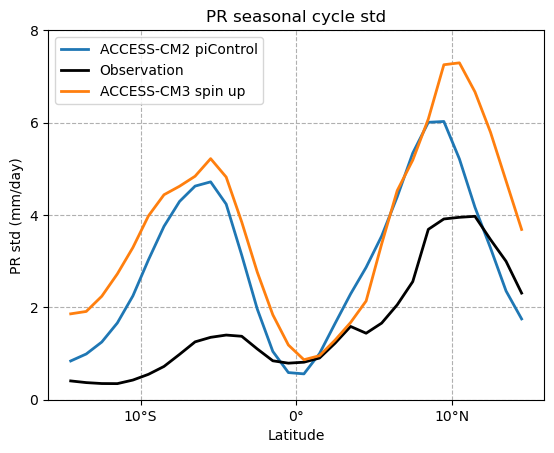

In [18]:
import iris.quickplot as qplt
import matplotlib.pyplot as plt

#plot 1
def format_latitude(x):
    if x < 0:
        return f'{abs(x)}°S'
    elif x > 0:
        return f'{x}°N'
    else:
        return '0°'

obs_data = obs_datasets_prep2["GPCP-SG"]
model_data = model_datasets_prep2["ACCESS-CM2"]
error = rmse(obs_data, model_data)

qplt.plot(model_data, label='ACCESS-CM2 piControl', linewidth=2)
qplt.plot(obs_data, color='black', label='Observation', linewidth=2)
qplt.plot(cm3_prep2, label='ACCESS-CM3 spin up', linewidth=2)

# plt.text(0.5, 0.95, f'RMSE: {error:.2f}', fontsize=12, ha='center', transform=plt.gca().transAxes,
#          bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.legend()
# ax = plt.gca()
plt.grid(linestyle='--')
plt.title('PR seasonal cycle std')

plt.yticks(np.arange(0,9, step=2))
plt.ylabel('PR std (mm/day)')

xt = np.arange(-10,15,step=10)
xlab = [format_latitude(x) for x in xt]
plt.xticks(xt,xlab)
plt.xlabel('Latitude')

Figure 1: Meridional bias in the amplitude of the mean seasonal precipitation cycle (PR) in the eastern Pacific (averaged between 150–90°W).

## Diagnostics level 2

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

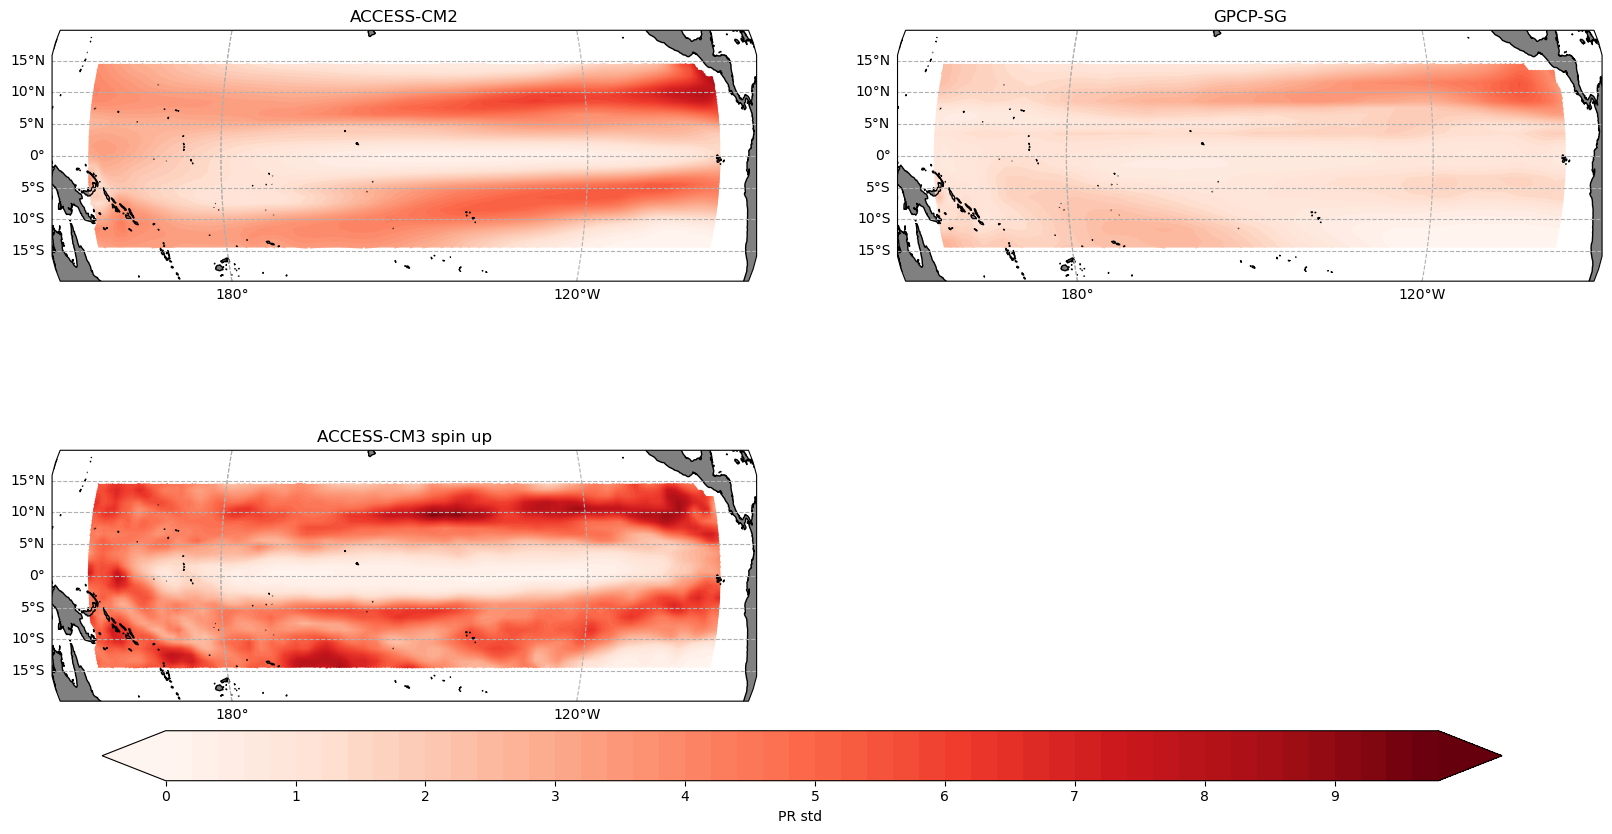

In [19]:
import iris.plot as iplt
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import cartopy.crs as ccrs

fig = plt.figure(figsize=(20, 10))
proj = ccrs.Orthographic(central_longitude=210.0)
i =221
process = {**model_datasets_prep1, **obs_datasets_prep1, 'ACCESS-CM3 spin up': cm3_prep1}


for label, cube in process.items():
    
    ax1 = plt.subplot(i,projection=proj)
    ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
    ax1.coastlines()
    cf1 = iplt.contourf(cube, levels=np.arange(0,10,0.2), extend='both', cmap='Reds')

    ax1.set_extent([130, 290, -20, 20], crs=ccrs.PlateCarree())
    ax1.set_title(label)

    # Add gridlines for latitude and longitude
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False

    i+=1


# Add a single colorbar at the bottom
cax = plt.axes([0.15,0.08,0.7,0.05])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(0,10,1))
cbar.set_label('PR std ')

Figure 2: Bias in the amplitude of the mean seasonal cycle of precipitation (PR) in the equatorial Pacific.

# Diagnostic level 3

The third level shows the meridional structure of the mean seasonal cycle in a Hovmöller diagram

In [20]:
def preproc3(cube):
    nino3_latext_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="monthly")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube = zonal_statistics(cube, operator='mean')
    
    return cube

In [21]:
model_datasets_prep3 = {name: preproc3(dataset) for name, dataset in model_datasets.items()}
obs_datasets_prep3 = {name: preproc3(dataset) for name, dataset in obs_datasets.items()}
cm3_prep3 = preproc3(cm3_cube)

process = {**model_datasets_prep3, 'ACCESS-CM3 spin up': cm3_prep3}

ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
ERROR:fiona._env:/opt/conda/analysis3-25

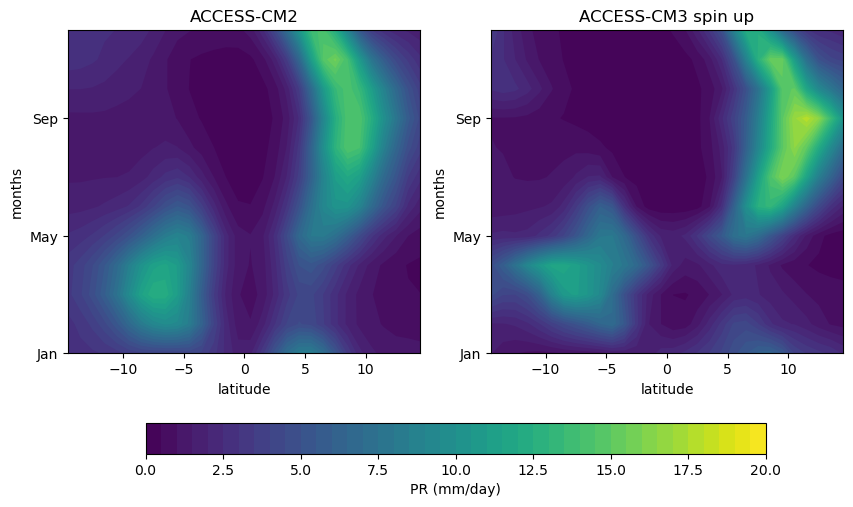

In [22]:
fig = plt.figure(figsize=(10, 6))
i=121

# Define tick positions and labels for the y-axis (months)
month_ticks = np.arange(1, 13, 4)
month_labels =['Jan', 'May', 'Sep'] 

axls =[]
for label, cube in process.items():
    
    ax1 = plt.subplot(i)
    cf1 = iplt.contourf(cube,coords=['latitude','month_number'],levels=np.arange(0,20.5,0.5),cmap="viridis")
    ax1.set_ylim(1, 12)
    ax1.set_yticks(ticks=month_ticks, labels=month_labels)
    ax1.set_title(label)
    ax1.set_ylabel("months")
    ax1.set_xlabel("latitude")
    axls.append(ax1)
    i+=1

# Add a single colorbar at the bottom
cbar = fig.colorbar(cf1, ax=axls, orientation='horizontal',shrink=0.8, extend='both')
cbar.set_label('PR (mm/day)')

Figure 3: Meridional structure of the mean seasonal cycle of precipitation (PR) in the eastern Pacific (averaged between 150–90°W).

In [23]:
client.close()